Starting Skincare Review Analysis with Direct Word Extraction...
Loading data from ../data/reviews_1250-end.csv...
Loaded 49977 reviews.

Extracting words by sentiment...
Extracting word bags from reviews...
Extracted 18144 unique positive words, 8400 unique negative words, and 6685 unique neutral words.

Analyzing word sentiment distribution...
Analyzing word sentiment distribution...

Top positive words:
  it: 87544
  my: 68296
  skin: 46980
  to: 46725
  is: 39880
  for: 29786
  of: 25574
  product: 25417
  in: 22871
  have: 22208

Top negative words:
  it: 14454
  to: 7838
  my: 7461
  for: 5206
  skin: 4703
  not: 4533
  is: 4395
  of: 4324
  product: 4294
  wa: 3556

Words with strong sentiment bias (appearing in both positive and negative reviews):
  amazed: 0.99 bias towards positive (pos: 193, neg: 1)
  nutrition: 0.99 bias towards positive (pos: 184, neg: 1)
  changer: 0.99 bias towards positive (pos: 352, neg: 2)
  healthier: 0.99 bias towards positive (pos: 324, neg: 2)
  p

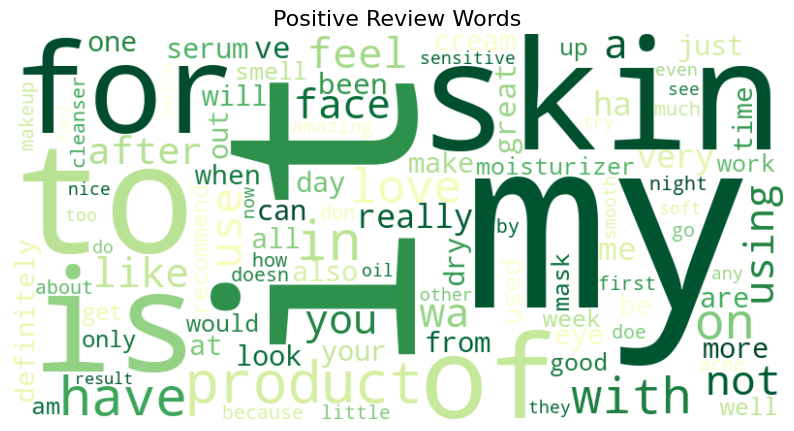

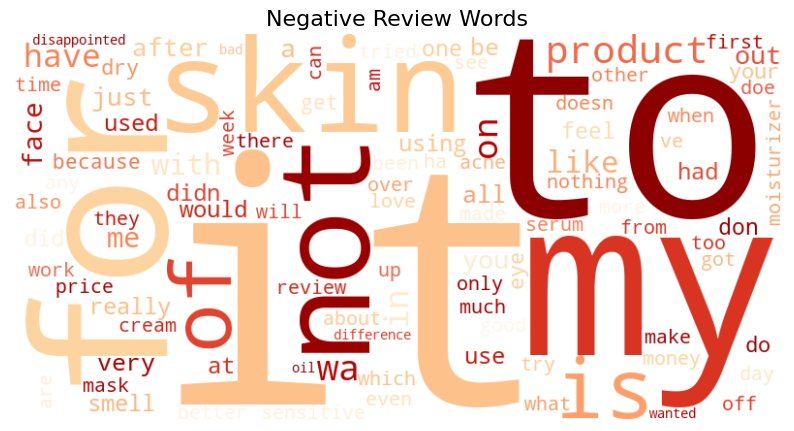

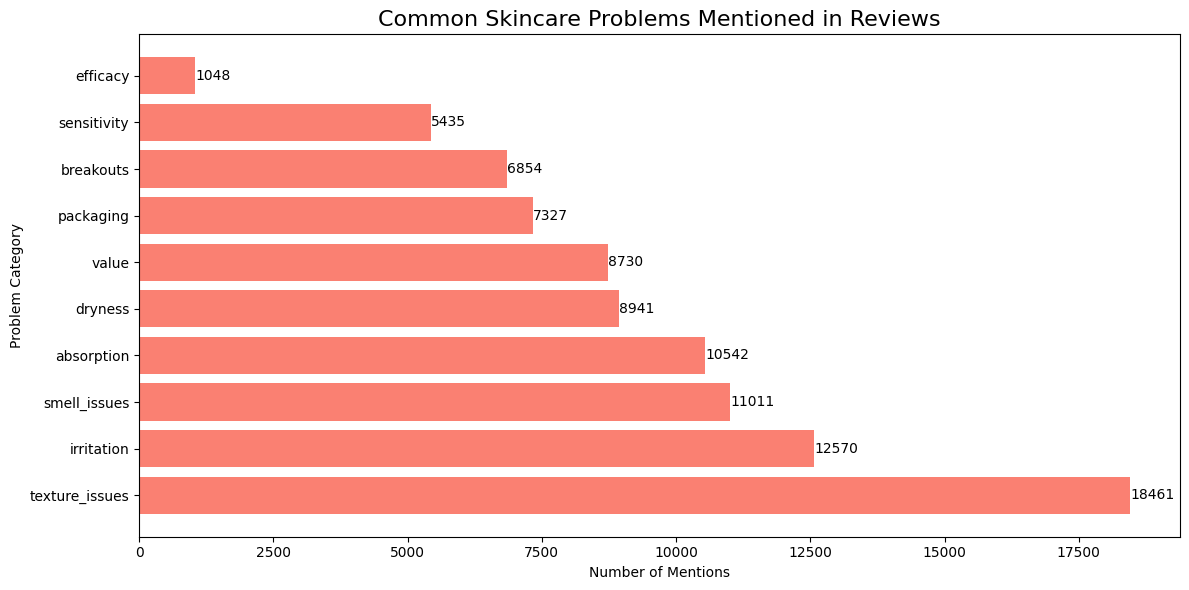

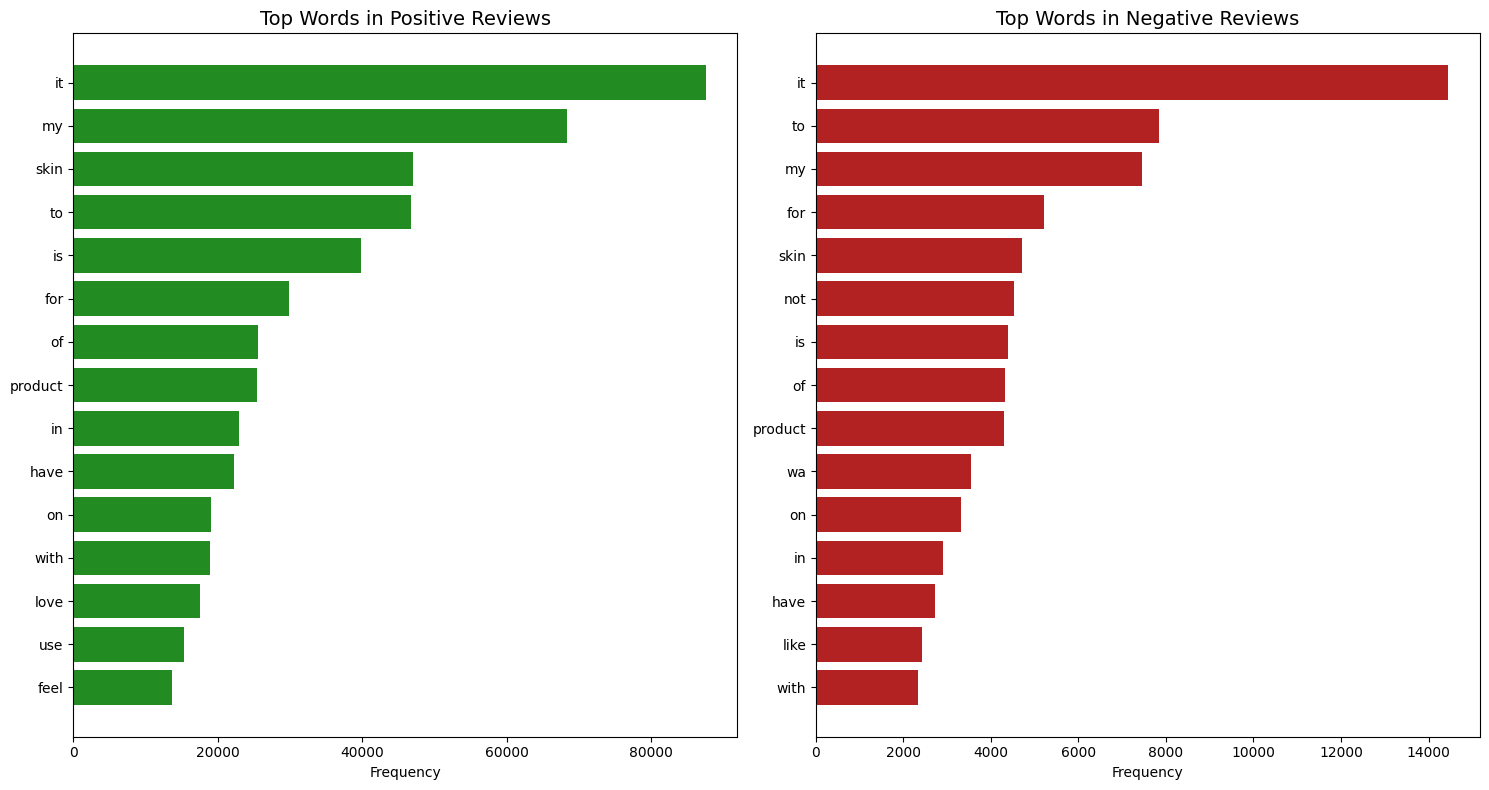

In [3]:
import pandas as pd
import os
from direct_text_analyzer import DirectTextAnalyzer

def main():
    """
    Example script for analyzing skincare review data using direct word extraction.
    This approach doesn't use standard stopwords, allowing for a more direct analysis
    of what customers say in reviews.
    """
    print("Starting Skincare Review Analysis with Direct Word Extraction...")
    
    # Define input file and output directory
    input_file = "../data/reviews_1250-end.csv"  # Change this to your input file path
    output_dir = "../output/skincare_word_analysis"
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    # Check if file exists
    if not os.path.exists(input_file):
        print(f"Error: Input file '{input_file}' not found.")
        return
    
    try:
        # Load the data (assuming tab-separated values)
        print(f"Loading data from {input_file}...")
        df = pd.read_csv(input_file, sep=None, engine='python')
        print(f"Loaded {len(df)} reviews.")
        
        # Initialize analyzer
        analyzer = DirectTextAnalyzer(df=df)
        
        # Step 1: Extract word bags by sentiment
        print("\nExtracting words by sentiment...")
        word_bags = analyzer.extract_word_bags(
            text_column="review_text",
            rating_column="rating",
            sentiment_threshold=3
        )
        
        # Step 2: Analyze word sentiment distribution
        print("\nAnalyzing word sentiment distribution...")
        word_sentiment = analyzer.analyze_word_sentiment_distribution(min_frequency=1)
        
        # Step 3: Extract common phrases (bigrams and trigrams)
        print("\nExtracting common phrases...")
        bigrams = analyzer.extract_ngrams(n=2, min_frequency=1)
        trigrams = analyzer.extract_ngrams(n=3, min_frequency=1)
        
        # Step 4: Analyze common skincare problems
        print("\nIdentifying common skincare problems...")
        problems = analyzer.analyze_common_problems()
        
        # Step 5: Analyze product-specific issues
        print("\nAnalyzing product-specific issues...")
        product_analysis = analyzer.analyze_product_specific_issues(min_reviews=1)
        
        # Step 6: Generate visualizations
        print("\nGenerating visualizations...")
        analyzer.visualize_word_cloud(
            sentiment='positive', 
            filename=os.path.join(output_dir, 'positive_words.png')
        )
        
        analyzer.visualize_word_cloud(
            sentiment='negative', 
            filename=os.path.join(output_dir, 'negative_words.png')
        )
        
        analyzer.visualize_common_problems(
            filename=os.path.join(output_dir, 'skincare_problems.png')
        )
        
        analyzer.visualize_sentiment_comparison(
            filename=os.path.join(output_dir, 'sentiment_comparison.png')
        )
        
        # Step 7: Generate comprehensive report
        print("\nGenerating comprehensive analysis report...")
        report_path = analyzer.generate_comprehensive_analysis(
            output_dir=output_dir,
            format='html'  # Options: 'html', 'markdown', 'text'
        )
        
        print(f"\nAnalysis complete! Results saved to '{output_dir}' directory.")
        print(f"Review the main report at: {report_path}")
        
    except Exception as e:
        print(f"Error during analysis: {str(e)}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()